In [1]:
!pip install torch numpy networkx matplotlib gym pygraphviz stable-baselines3

In [2]:
!pip install pydot

In [1]:
import gymnasium as gym
import numpy as np
import networkx as nx
import torch
import matplotlib.pyplot as plt
import os
import random
from gymnasium import spaces
from xing import XingLoss

## define the env

In [7]:
MAX_NODES = 100

class GraphLayoutEnv(gym.Env):
    def __init__(self, graph_paths, max_steps=500, move_penalty=0.001):
        super(GraphLayoutEnv, self).__init__()
        
        self.graph_paths = graph_paths
        self.max_steps = max_steps
        self.move_penalty = move_penalty
        
        # 固定大小，不依赖n_nodes
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(MAX_NODES * 2 + 1,),
            dtype=np.float32
        )
        
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, -1.0]),
            high=np.array([1.0, 1.0, 1.0]),
            dtype=np.float32
        )
        
        # 这些都在reset时才初始化
        self.G = None
        self.n_nodes = None
        self.xing_loss = None
        self.coords = None
        self.current_crossings = None
        self.steps = 0
        self.no_improve_steps = 0
        
    def _pos_to_coords(self, pos):
        nodes = list(self.G.nodes())
        coords = np.array([[pos[v][0], pos[v][1]] for v in nodes], 
                          dtype=np.float32)
        return coords
    
    def _normalize_coords(self, coords):
        min_val = coords.min()
        max_val = coords.max()
        if max_val - min_val < 1e-6:
            return coords
        return 2 * (coords - min_val) / (max_val - min_val) - 1
    
    def _get_obs(self):
        coords_norm = self._normalize_coords(self.coords)
        coords_flat = coords_norm.flatten()
        padded = np.zeros(MAX_NODES * 2 + 1, dtype=np.float32)
        padded[:len(coords_flat)] = coords_flat
        padded[-1] = self.current_crossings / (self.G.number_of_edges()**2 + 1e-6)
        return padded
    
    def _compute_crossings(self, coords):
        coords_tensor = torch.tensor(coords, dtype=torch.float32)
        with torch.no_grad():
            crossings = self.xing_loss(coords_tensor).item()
        return crossings
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # 随机选一张图
        graph_path = random.choice(self.graph_paths)
        self.G = nx.read_graphml(graph_path)
        self.G = nx.convert_node_labels_to_integers(self.G, ordering="sorted")
        self.n_nodes = self.G.number_of_nodes()
        self.xing_loss = XingLoss(self.G, soft=False)
        
        # neato初始布局
        pos = nx.nx_agraph.graphviz_layout(self.G, prog="neato")
        self.coords = self._pos_to_coords(pos)
        self.current_crossings = self._compute_crossings(self.coords)
        self.steps = 0
        self.no_improve_steps = 0
        return self._get_obs(), {}
    
    def step(self, action):
        node_idx = int((action[0] + 1) / 2 * self.n_nodes)
        node_idx = np.clip(node_idx, 0, self.n_nodes - 1)
        delta_x = action[1] * 50
        delta_y = action[2] * 50
        
        old_crossings = self.current_crossings
        
        new_coords = self.coords.copy()
        new_coords[node_idx, 0] += delta_x
        new_coords[node_idx, 1] += delta_y
        
        new_crossings = self._compute_crossings(new_coords)
        
        crossing_improvement = old_crossings - new_crossings
        move_distance = np.sqrt(delta_x**2 + delta_y**2)
        reward = float(crossing_improvement) - self.move_penalty * move_distance
        
        self.coords = new_coords
        self.current_crossings = new_crossings
        self.steps += 1
        
        if crossing_improvement <= 0:
            self.no_improve_steps += 1
        else:
            self.no_improve_steps = 0
        
        terminated = bool(self.current_crossings == 0)
        truncated = bool(self.steps >= self.max_steps)
        
        info = {
            "crossings": self.current_crossings,
            "crossing_improvement": crossing_improvement,
            "steps": self.steps
        }
        
        return self._get_obs(), reward, terminated, truncated, info
    
    def render(self):
        nodes = list(self.G.nodes())
        pos = {nodes[i]: (self.coords[i, 0], self.coords[i, 1]) 
               for i in range(self.n_nodes)}
        plt.figure(figsize=(6, 6))
        nx.draw(self.G, pos, with_labels=False, 
                node_size=30, node_color='lightblue', edge_color='gray')
        plt.title(f"Crossings: {int(self.current_crossings)}")
        plt.show()

In [3]:
# list all the graphs
rome_dir = "/Users/apple/Desktop/cs5180 Reinforcement Learning/project/cs5180/rome"
train_graphs = []
for fname in os.listdir(rome_dir):
    if not fname.endswith(".graphml"):
        continue
    try:
        graph_num = int(fname.split("grafo")[1].split(".")[0])
    except:
        continue
    if graph_num > 9999:
        continue
    fpath = os.path.join(rome_dir, fname)
    G_tmp = nx.read_graphml(fpath)
    if G_tmp.number_of_nodes() <= MAX_NODES:
        train_graphs.append(fpath)

print(f"Total training graphs: {len(train_graphs)}")

Total training graphs: 9872


## PPO

In [10]:
!pip install stable-baselines3

In [8]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# 创建环境
env = GraphLayoutEnv(train_graphs, max_steps=500, move_penalty=0.001)

# 检查环境
check_env(env)
print("Environment check passed!")

# 训练PPO
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
)

model.learn(total_timesteps=500000)
model.save("ppo_graph_layout")
print("Training done!")

Environment check passed!
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -87.6    |
| time/              |          |
|    fps             | 1099     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 427          |
|    ep_rew_mean          | -62.1        |
| time/                   |              |
|    fps                  | 1052         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0077224113 |
|    clip_fraction        | 0.077        |
|    clip_range         

neato baseline crossings: 50.0
Initial crossings (neato): 50.0
Final crossings (PPO): 84.0
Improvement: -34.0


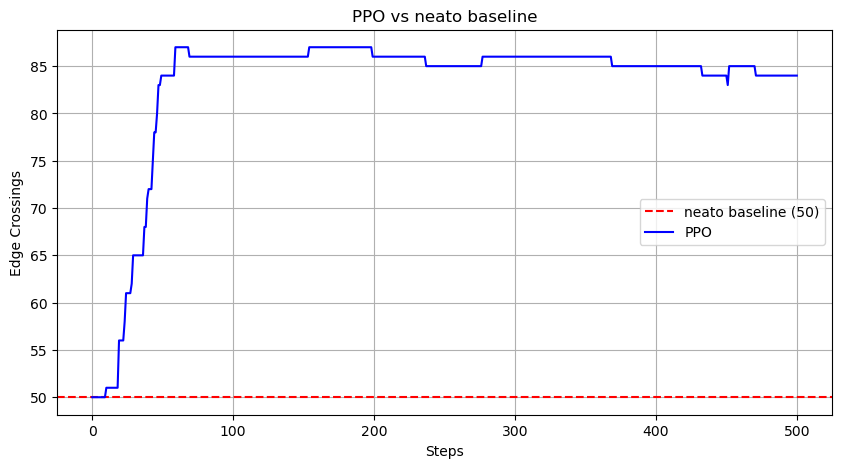

In [10]:
# 用一张具体的图测试
test_path = "/Users/apple/Desktop/cs5180 Reinforcement Learning/project/cs5180/rome/grafo4647.62.graphml"
G_test = nx.read_graphml(test_path)
G_test = nx.convert_node_labels_to_integers(G_test, ordering="sorted")

# 算neato baseline
pos_neato = nx.nx_agraph.graphviz_layout(G_test, prog="neato")
coords_neato = torch.tensor(
    [[pos_neato[v][0], pos_neato[v][1]] for v in G_test.nodes()],
    dtype=torch.float32
)
neato_crossings = XingLoss(G_test, soft=False)(coords_neato).item()
print(f"neato baseline crossings: {neato_crossings}")

# 用PPO优化
test_env = GraphLayoutEnv([test_path], max_steps=500)
obs, _ = test_env.reset()
crossing_history = [test_env.current_crossings]
print(f"Initial crossings (neato): {test_env.current_crossings}")

done = False
truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)
    crossing_history.append(info['crossings'])

print(f"Final crossings (PPO): {test_env.current_crossings}")
print(f"Improvement: {neato_crossings - test_env.current_crossings}")

# 画图
plt.figure(figsize=(10, 5))
plt.axhline(y=neato_crossings, color='red', 
            linestyle='--', label=f'neato baseline ({int(neato_crossings)})')
plt.plot(crossing_history, label="PPO", color='blue')
plt.xlabel("Steps")
plt.ylabel("Edge Crossings")
plt.title("PPO vs neato baseline")
plt.legend()
plt.grid(True)
plt.show()

## Cell 5：测试一张图的效果

In [11]:
# 只用一张图训练
single_graph = ["/Users/apple/Desktop/cs5180 Reinforcement Learning/project/cs5180/rome/grafo4647.62.graphml"]

env_single = GraphLayoutEnv(single_graph, max_steps=500, move_penalty=0.001)

model_single = PPO(
    "MlpPolicy",
    env_single,
    verbose=1,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
)

model_single.learn(total_timesteps=500000)
model_single.save("ppo_single_graph")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -183     |
| time/              |          |
|    fps             | 650      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 500          |
|    ep_rew_mean          | -169         |
| time/                   |              |
|    fps                  | 656          |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0051009376 |
|    clip_fraction        | 0.0382       |
|    clip_range           | 0.2          |
|    en

In [ ]:
test_env = GraphLayoutEnv(single_graph, max_steps=500)
obs, _ = test_env.reset()
crossing_history = [test_env.current_crossings]

done = False
truncated = False
while not (done or truncated):
    action, _ = model_single.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)
    crossing_history.append(info['crossings'])

print(f"neato: 50, PPO: {test_env.current_crossings}")